In [3]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")
print(df.shape)
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True))

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [4]:
print(df.isnull().sum().sum(), "missing values")
print(df[["Time", "Amount"]].describe())
print(df.groupby("Class")["Amount"].describe())

0 missing values
                Time         Amount
count  284807.000000  284807.000000
mean    94813.859575      88.349619
std     47488.145955     250.120109
min         0.000000       0.000000
25%     54201.500000       5.600000
50%     84692.000000      22.000000
75%    139320.500000      77.165000
max    172792.000000   25691.160000
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [5]:
df = df.sort_values("Time")
cut = int(len(df) * 0.8)
train, test = df.iloc[:cut], df.iloc[cut:]

print("Train:", len(train), "rows | frauds:", train["Class"].sum(), "| rate:", round(train["Class"].mean() * 100, 3), "%")
print("Test: ", len(test), "rows | frauds:", test["Class"].sum(), "| rate:", round(test["Class"].mean() * 100, 3), "%")
print("Train time range:", train["Time"].min(), "to", train["Time"].max())
print("Test time range: ", test["Time"].min(), "to", test["Time"].max())

Train: 227845 rows | frauds: 417 | rate: 0.183 %
Test:  56962 rows | frauds: 75 | rate: 0.132 %
Train time range: 0.0 to 145247.0
Test time range:  145248.0 to 172792.0


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import average_precision_score

X_tr, y_tr = train.drop(columns="Class"), train["Class"]
X_te, y_te = test.drop(columns="Class"), test["Class"]

model = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000))
model.fit(X_tr, y_tr)
scores = model.predict_proba(X_te)[:, 1]

print("PR-AUC:", round(average_precision_score(y_te, scores), 4))
print("Random-guess PR-AUC (fraud rate in test):", round(y_te.mean(), 4))

PR-AUC: 0.762
Random-guess PR-AUC (fraud rate in test): 0.0013


Matplotlib is building the font cache; this may take a moment.


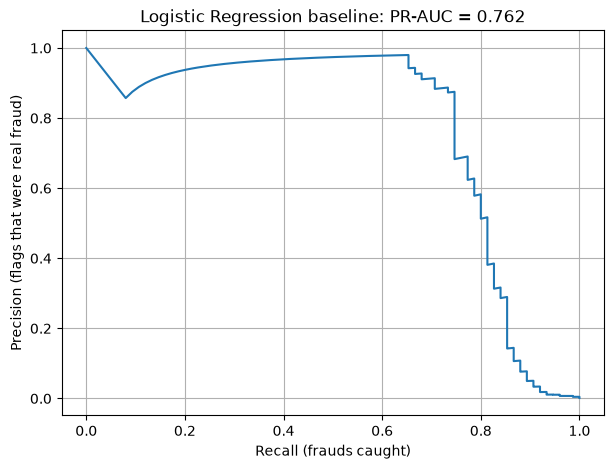

In [7]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_te, scores)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall (frauds caught)")
plt.ylabel("Precision (flags that were real fraud)")
plt.title("Logistic Regression baseline: PR-AUC = 0.762")
plt.grid(True)
plt.savefig("../baseline_pr_curve.png", dpi=120, bbox_inches="tight")
plt.show()